In [2]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [3]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [4]:
model = DecisionTreeClassifier(
    random_state=42
)

In [5]:
model.fit(X_train, y_train)

print("Decision Tree trained!")

Decision Tree trained!


In [6]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [7]:
print("="*50)

print("Accuracy")

print(accuracy_score(y_test, y_pred))

Accuracy
0.725


In [8]:
print("="*50)

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.15      0.18      0.17        60
           1       0.85      0.82      0.84       340

    accuracy                           0.72       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.75      0.72      0.74       400



In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 11  49]
 [ 61 279]]


In [10]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC")

print(auc)

AUC
0.5019607843137255


In [11]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
1,CreditScore,0.080745
2,MonthlyIncome,0.076477
6,SessionHour,0.073023
7,SessionDay,0.070449
0,Age,0.059699
9,TotalAmount,0.045616
5,Quantity,0.040478
8,SessionMonth,0.031474
126,Weekday_Sunday,0.020536
4,Price,0.020350


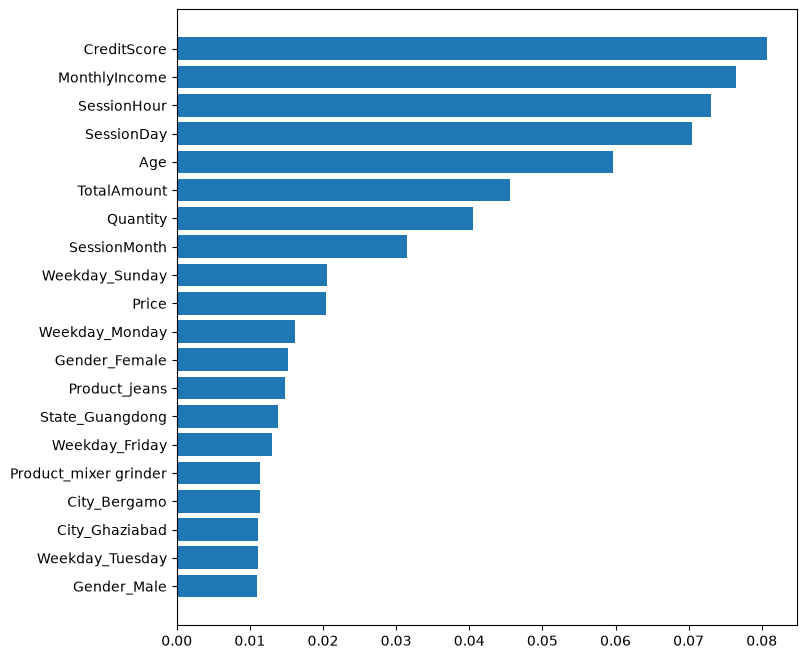

In [12]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(8,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.show()

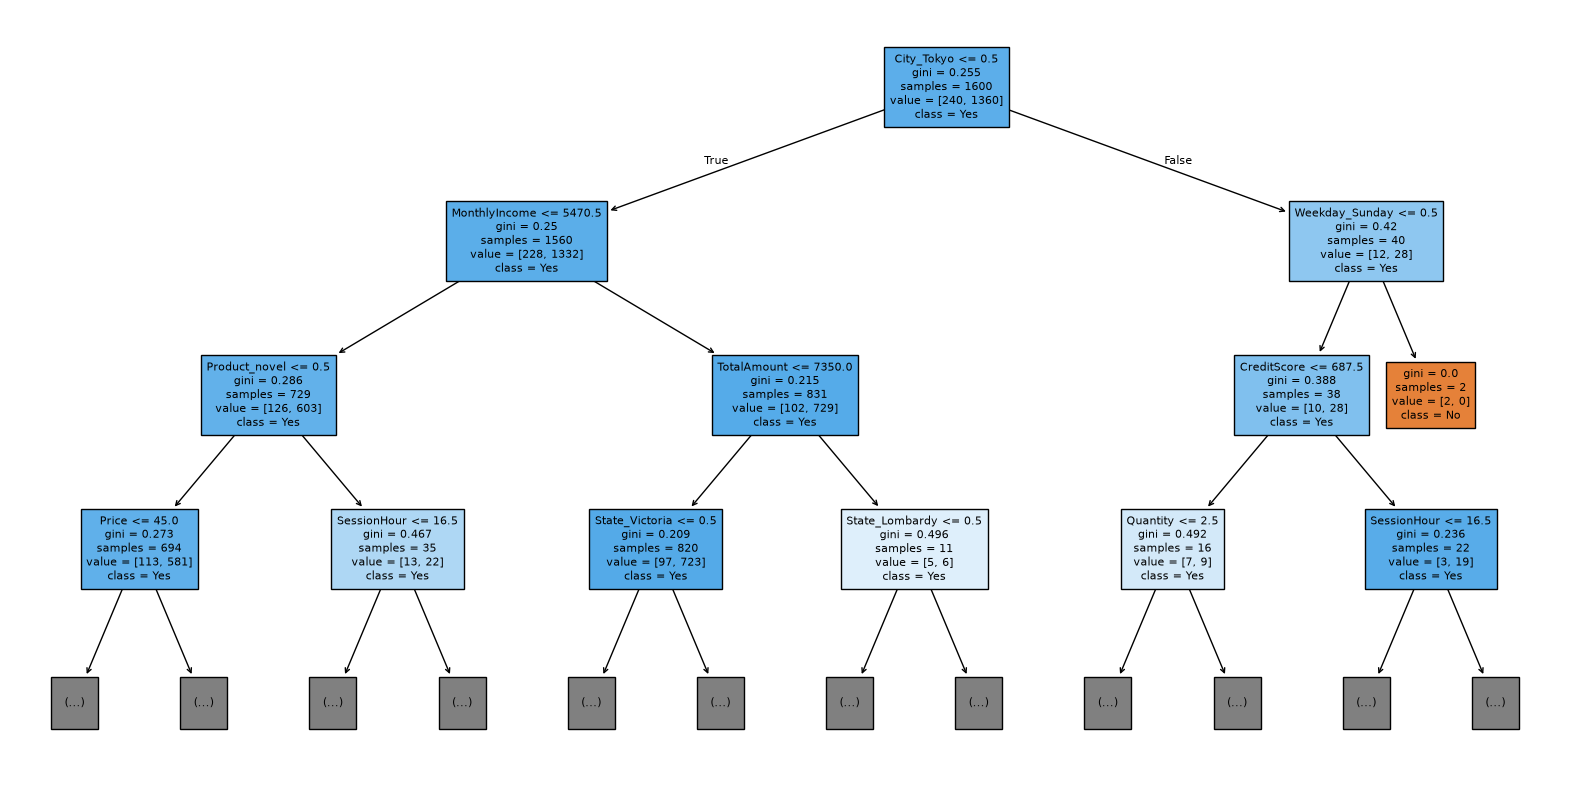

In [13]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(
    model,
    filled=True,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=["No","Yes"],
    fontsize=8
)

plt.show()

In [14]:
train_acc = model.score(
    X_train,
    y_train
)

test_acc = model.score(
    X_test,
    y_test
)

print(train_acc)

print(test_acc)

1.0
0.725


In [15]:
model2 = DecisionTreeClassifier(

    max_depth=5,

    random_state=42

)

model2.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 